In [1]:
import datetime as dt
from functools import partial
from jax import numpy as jnp
from numpyro import distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
import numpyro
import jax
import arviz as az

import matplotlib as mpl
import numpy as np
import skfda
import xarray as xr
from matplotlib import pyplot as plt
from skfda.representation.basis import BSplineBasis, FourierBasis
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline

from src.data_loading import load_data
from src.preprocessing import (
    BasisFunctionTransformer,
    WindowTransformer,
    XArrayStandardScaler,
    time_window_generator,
)
from src.utils import flatten_array

numpyro.set_host_device_count(4)

# Setup

For a chosen training window size, we want to generate training samples from a rolling window. Then, we will use each training window of that size to train models for the next 12 months. We will load our RNBS data and focus on estimating the data using only the autoregressive features for now. However, we also have covariates that are important for our final model.


In [2]:
rnbs = load_data("rnbs")
scaler = XArrayStandardScaler()
scaler.fit(rnbs)

train_window_size = 36


training_windows = list(
    time_window_generator(rnbs, train_window_size, 12, reindex_domain=False)
)

train, test = training_windows[-1]

train, test

(<xarray.DataArray 'rnbs' (Date: 36, lake: 4)> Size: 1kB
 array([[   2.942399,   48.82321 ,  101.2149  ,  131.6718  ],
        [  71.16597 ,   99.1696  ,  166.6509  ,  255.5716  ],
        [  60.48264 ,  122.1726  ,  112.8125  ,  260.542   ],
        [ 197.4255  ,  299.6827  ,  288.7482  ,  417.5179  ],
        [ 199.4292  ,  285.3751  ,  215.0817  ,  418.8283  ],
        [ 107.8879  ,  196.7569  ,  229.5701  ,  273.8267  ],
        [ 122.5999  ,   94.20816 ,   26.35805 ,  135.8741  ],
        [  58.84797 ,   -7.334942,  -66.4223  ,    7.003818],
        [ 134.7808  ,  127.1045  ,  -49.99528 ,   37.95617 ],
        [  68.65597 ,   79.30906 ,  -89.61738 ,  128.8702  ],
        [   7.909673,   75.64159 ,   12.24374 ,  149.1135  ],
        [  35.96265 ,  107.732   ,  -27.41238 ,  222.7214  ],
        [  12.75039 ,  129.966   ,  239.3311  ,  334.7825  ],
        [ -29.97239 ,   43.52904 ,   38.46575 ,  163.799   ],
        [  94.15675 ,  170.9958  ,  212.9731  ,  369.8016  ],
        [  89

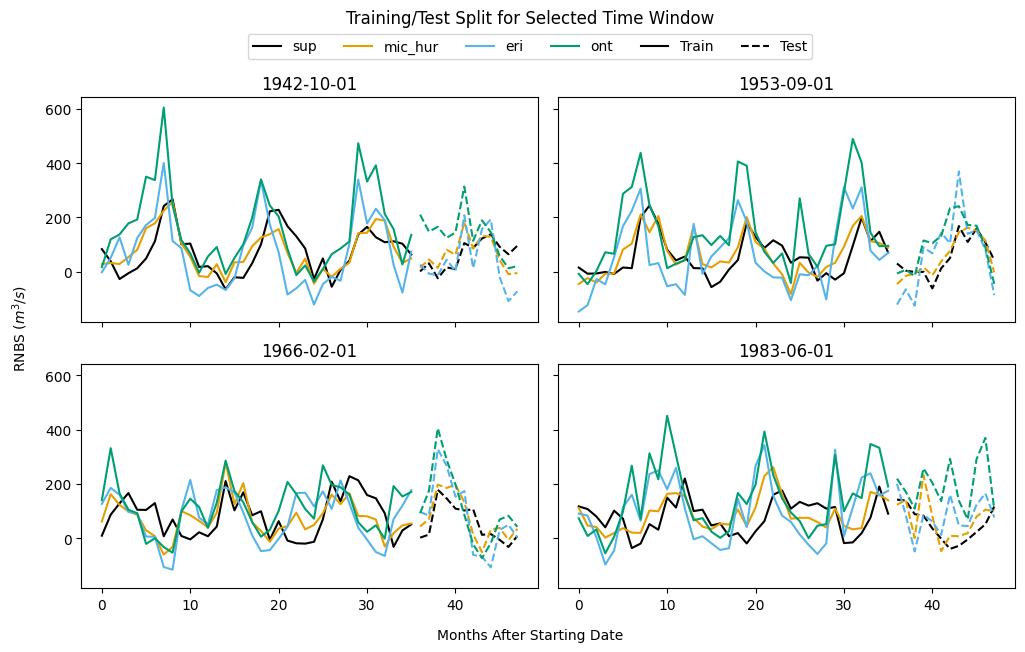

In [3]:
# colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [
    "#000000",  # black
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
]

fig, ax = plt.subplots(figsize=(10, 6), sharex=True, sharey=True, nrows=2, ncols=2)
rng = np.random.default_rng(20250607)
window_idx = np.sort(rng.choice(len(training_windows), size=4, replace=False))
for i, ax_idx in enumerate(ax.flatten()):
    train, test = training_windows[window_idx[i]]
    start_date = np.datetime_as_string(train.coords["Date"].values[0], unit="D")

    for j in range(4):
        ax_idx.plot(
            list(range(36)),
            train[:, j],
            label=train.coords["lake"][j].values,
            color=colors[j],
        )
        ax_idx.plot(list(range(36, 48)), test[:, j], linestyle="--", color=colors[j])

    ax_idx.set_title(start_date)

handles, labels = ax[0, 0].get_legend_handles_labels()
blank_handle = mpl.lines.Line2D([0], [0], color="none", linestyle="")
dataset_handles = [
    mpl.lines.Line2D([0], [0], color="black", linestyle="-"),
    mpl.lines.Line2D([1], [1], color="black", linestyle="--"),
]

# handles = [handles[0], blank_handle, handles[1], dataset_handles[0], handles[2], dataset_handles[1], handles[3]]
handles = [*handles, *dataset_handles]
labels = [*labels, "Train", "Test"]

fig.text(-0.02, 0.5, "RNBS $(m^3/s)$", va="center", rotation="vertical")
fig.text(0.5, -0.02, "Months After Starting Date", ha="center")
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=6)

fig.suptitle("Training/Test Split for Selected Time Window", y=1.03)
fig.tight_layout()

# Data Setup

Once we have all of these training sets, compile them together into a single data object. We have a high dimensional object for multiple lakes, so this should be an $N \times M \times L$ array, where $N$ is the number of training windows, $M$ is training window size, and $L$ is the number of lakes.



In [4]:
scaled_train_windows, scaled_test_windows = [
    (scaler.transform(window[0]), scaler.transform(window[1]))
    for window in zip(
        *list(time_window_generator(rnbs, train_window_size, 12, reindex_domain=True))
    )
]


In [5]:
all_data = (
    load_data(["rnbs", "evap", "temp", "precip"])
    .sel(type="Basin")
    .drop_vars("type")
    .to_array()
    .transpose("Date", "lake", ...)
    .dropna("Date")
)

scaler = XArrayStandardScaler()
scaled_data = scaler.fit_transform(all_data)

scaled_data

<xarray.DataArray (Date: 384, lake: 4, variable: 4)> Size: 49kB
array([[[-1.18710356,  1.59636823, -1.86339915, -0.86062917],
        [-0.47976789, -0.64420969, -1.73947496,  0.35468503],
        [ 0.11801005, -1.1180118 , -1.71392113,  0.24179939],
        [ 0.73152607, -0.89906412, -1.5326988 ,  2.3412617 ]],

       [[-0.39699687, -1.1510496 , -1.85293383, -0.35579947],
        [-0.49125506, -1.33669025, -1.95883029, -1.16319405],
        [ 0.58866456, -1.26372941, -1.9606346 , -0.94415799],
        [-0.47626258, -1.16378873, -2.08548358, -0.89567824]],

       [[ 1.14108578, -1.06272314, -0.94245105,  2.29637504],
        [ 2.22787517, -1.61221047, -0.92625519,  1.88100459],
        [ 1.79230574, -1.08978563, -0.85578734,  0.63673246],
        [ 2.43288709, -1.31458122, -0.69289114, -0.20792194]],

       ...,

       [[-1.3763873 ,  1.08849107,  0.45990172,  0.08647209],
        [-1.71168138,  0.34011111,  0.38452666, -0.64832497],
        [-1.14488754, -0.18407837,  0.33487331, -0.51216375],
        [-0.28009409,  0.13063323,  0.30637366, -0.09204996]],

       [[-0.82929638,  1.18727725, -0.20987871,  0.86626668],
        [-1.24319411, -0.30468941, -0.30564011, -0.27835073],
        [-0.82607692, -0.81775591, -0.39454042,  0.56608461],
        [-0.06612586, -0.66641284, -0.36334637,  0.33779772]],

       [[-1.65558078,  1.80556248, -1.00524297, -0.81552911],
        [-1.0893084 ,  0.16123096, -1.12421001, -0.43027932],
        [-0.73348909, -0.64028386, -1.31703425, -0.7634848 ],
        [ 0.19122886, -0.28775612, -1.20315402,  0.60318194]]],
      shape=(384, 4, 4))
Coordinates:
  * Date      (Date) datetime64[ns] 3kB 1979-01-01 1979-02-01 ... 2010-12-01
  * lake      (lake) object 32B 'sup' 'mic_hur' 'eri' 'ont'
  * variable  (variable) object 32B 'rnbs' 'evap' 'temp' 'precip'

## Generating Training Data with Covariates

This is slightly different than the original data. Normally, we predict scalars with scalars. Now, we 
convert our future covariate curves into functional objects, our response curves into functional objects, and our past autoregressive features into functional objects.
Then, we train the past autoregressive feature and the functional covariates to estimate the 12-month functional response.

### Functional Response

In [6]:
# get the windows
windower = WindowTransformer(train_size=24, test_size=12, reindex_domain=True)
prior, forecast = windower.fit_transform(scaled_data)

y_pipeline = BasisFunctionTransformer(partial(FourierBasis, n_basis=8))
train_targets = y_pipeline.fit_transform(forecast.sel(variable=["rnbs"]))



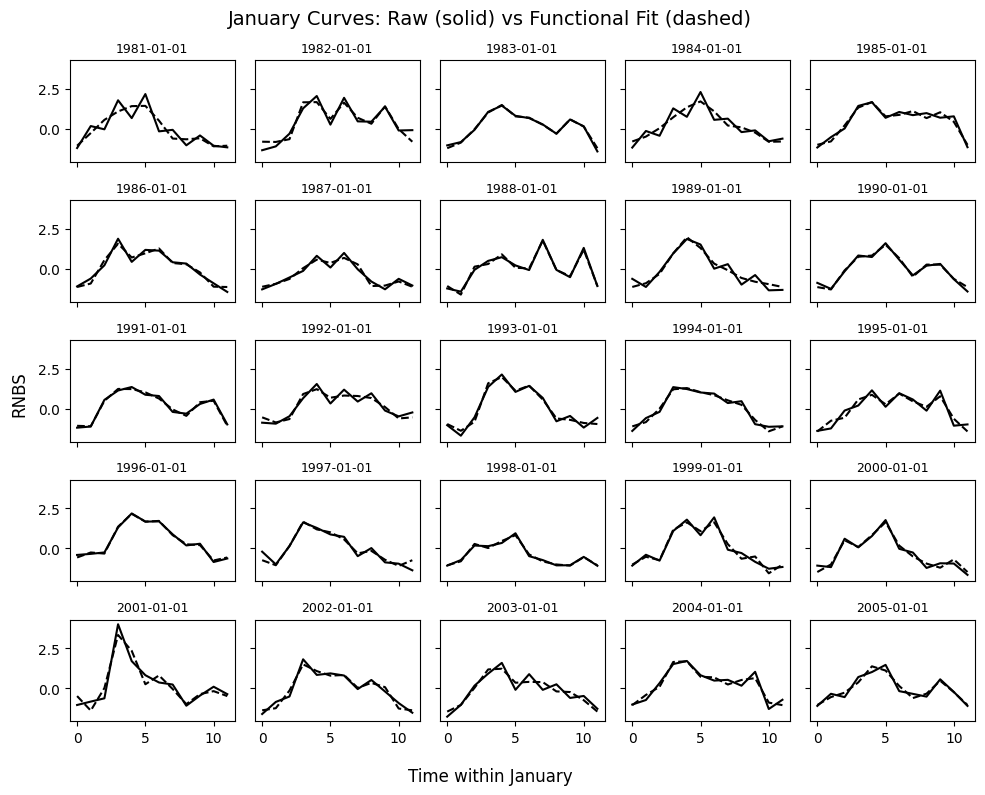

In [7]:
date_idx = list(range(0, 36 * 25, 12))  # 16 January curves
t = np.arange(0, 12, 1)

lake = "sup"
true_y = forecast.sel(variable="rnbs", lake=lake)
estimates = y_pipeline.basis_lookup[lake]["rnbs"](range(0, 12)).squeeze()

fig, axes = plt.subplots(5, 5, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, i in zip(axes, date_idx):
    # raw observed curve
    arr = true_y.squeeze()[i].values

    # functional reconstruction

    ax.plot(t, arr, color="black", linewidth=1.5)
    ax.plot(t, estimates[i].squeeze(), color="black", linestyle="--", linewidth=1.5)

    start_date = true_y.coords["start_date"].values[i]

    ax.set_title(f"{start_date}", fontsize=9)

fig.suptitle("January Curves: Raw (solid) vs Functional Fit (dashed)", fontsize=14)
fig.supxlabel("Time within January")
fig.supylabel("RNBS")

plt.tight_layout()
plt.show()

In [8]:
forecast.sel(variable="rnbs")

<xarray.DataArray (start_date: 349, Date: 12, lake: 4)> Size: 134kB
array([[[-1.1965678 , -0.84549217, -0.97267422, -1.10778345],
        [ 0.17573893,  0.63592872,  1.58244065,  1.60037709],
        [-0.02774108,  0.00786443, -0.08290543,  0.26020312],
        ...,
        [-0.41104045, -0.35144354, -0.37949506,  0.07627151],
        [-1.05368918, -0.78371029, -0.67793641,  0.33436812],
        [-1.15397895, -1.07326787, -0.18814696, -0.42953816]],

       [[ 0.17573893,  0.63592872,  1.58244065,  1.60037709],
        [-0.02774108,  0.00786443, -0.08290543,  0.26020312],
        [ 1.78556637,  1.89557783,  1.18307812,  0.33436812],
        ...,
        [-1.05368918, -0.78371029, -0.67793641,  0.33436812],
        [-1.15397895, -1.07326787, -0.18814696, -0.42953816],
        [-1.33379845, -0.37069217,  0.57724526, -0.54449503]],

       [[-0.02774108,  0.00786443, -0.08290543,  0.26020312],
        [ 1.78556637,  1.89557783,  1.18307812,  0.33436812],
        [ 0.67260842,  0.59815646,  0.41460004, -0.03868503],
        ...,
...
        [ 0.21832778, -0.69150304, -1.49888158, -1.03880937],
        [ 0.18734014, -0.73714102, -1.66862601, -1.04511345],
        [-1.3763873 , -1.71168138, -1.14488754, -0.28009409]],

       [[-1.0072841 , -1.02835435, -0.07333804,  0.06477635],
        [-1.461565  , -1.0443949 , -0.40819731, -0.0961633 ],
        [-1.35013184, -0.58687732, -0.60386621, -0.22706551],
        ...,
        [ 0.18734014, -0.73714102, -1.66862601, -1.04511345],
        [-1.3763873 , -1.71168138, -1.14488754, -0.28009409],
        [-0.82929638, -1.24319411, -0.82607692, -0.06612586]],

       [[-1.461565  , -1.0443949 , -0.40819731, -0.0961633 ],
        [-1.35013184, -0.58687732, -0.60386621, -0.22706551],
        [-0.48675391, -0.098003  ,  1.25653135,  1.29481441],
        ...,
        [-1.3763873 , -1.71168138, -1.14488754, -0.28009409],
        [-0.82929638, -1.24319411, -0.82607692, -0.06612586],
        [-1.65558078, -1.0893084 , -0.73348909,  0.19122886]]],
      shape=(349, 12, 4))
Coordinates:
  * start_date  (start_date) <U10 14kB '1981-01-01' ... '2010-01-01'
  * Date        (Date) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * lake        (lake) object 32B 'sup' 'mic_hur' 'eri' 'ont'
    variable    <U4 16B 'rnbs'
Attributes:
    start_date:  1981-01-01
    end_date:    1981-12-01

### Functional Covariates

In [154]:
import numpy as np
from matplotlib import pyplot as plt

covariates = forecast.sel(variable=["precip", "temp", "evap"])
print(covariates.shape, covariates.dims)

covar_basis = BasisFunctionTransformer(partial(FourierBasis, n_basis=8))
basis_covars = covar_basis.fit_transform(covariates).transpose('start_date', 'basis_dim', 'lake', 'variable')

print(basis_covars.shape, basis_covars.dims)

(349, 12, 4, 3) ('start_date', 'Date', 'lake', 'variable')
(349, 9, 4, 3) ('start_date', 'basis_dim', 'lake', 'variable')


# Initial Model Fit

In [ ]:
def model(X, KY=10, L=4, y=None):

    N, KX, L, M = X.shape

    
    rho = numpyro.sample("rho", dist.Uniform(0.8, 0.99))
    sigma_beta = numpyro.sample("sigma_beta", dist.HalfNormal(0.3))

    beta_global = []
    beta_prev = numpyro.sample(
        "beta_global_0",
        dist.Normal(0, 0.5).expand([KX, M]).to_event(2)
    )
    beta_global.append(beta_prev)

    for ky in range(1, KY):
        beta_next = numpyro.sample(
            f"beta_global_{ky}",
            dist.Normal(rho * beta_prev, sigma_beta).to_event(2)
        )
        beta_global.append(beta_next)
        beta_prev = beta_next

    beta_global = jnp.stack(beta_global, axis=1)  # (KX, KY, M)

    # beta_global = numpyro.sample(
    #     "beta_global",
    #     dist.Normal(0, 0.5)
    #     .expand([KX, KY, M])
    #     .to_event(3)
    # )
    
    sigma_lake = numpyro.sample(
        "sigma_lake",
        dist.HalfNormal(0.2)
    )

    with numpyro.plate("lake", L):
        z = numpyro.sample(
            "z",
            dist.Normal(0, 1)
            .expand([KX, KY, M])
            .to_event(3)
        )
        beta = numpyro.deterministic("beta", beta_global + z * sigma_lake)

    mu = numpyro.deterministic("mu", jnp.einsum("nklm,lkym->nyl", X, beta))
    sigma = numpyro.sample("sigma", dist.Exponential(1.0))
    
    if y is not None:
        y_out = numpyro.sample(
            "y",
            dist.Normal(mu, sigma),
            obs=y
        )
    else:
        y_out = numpyro.sample(
            "y",
            dist.Normal(mu, sigma)
        )
    numpyro.deterministic("y_hat", y_out)

key = jax.random.key(20250607)
kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=1000, num_chains=1)

ky = train_targets.sizes["basis_dim"]
L = train_targets.sizes["lake"]

mcmc.run(key, basis_covars.values, KY=ky, L=L, y=train_targets.squeeze().values)


sample: 100%|██████████| 2000/2000 [00:13<00:00, 146.64it/s, 63 steps of size 6.18e-02. acc. prob=0.87]


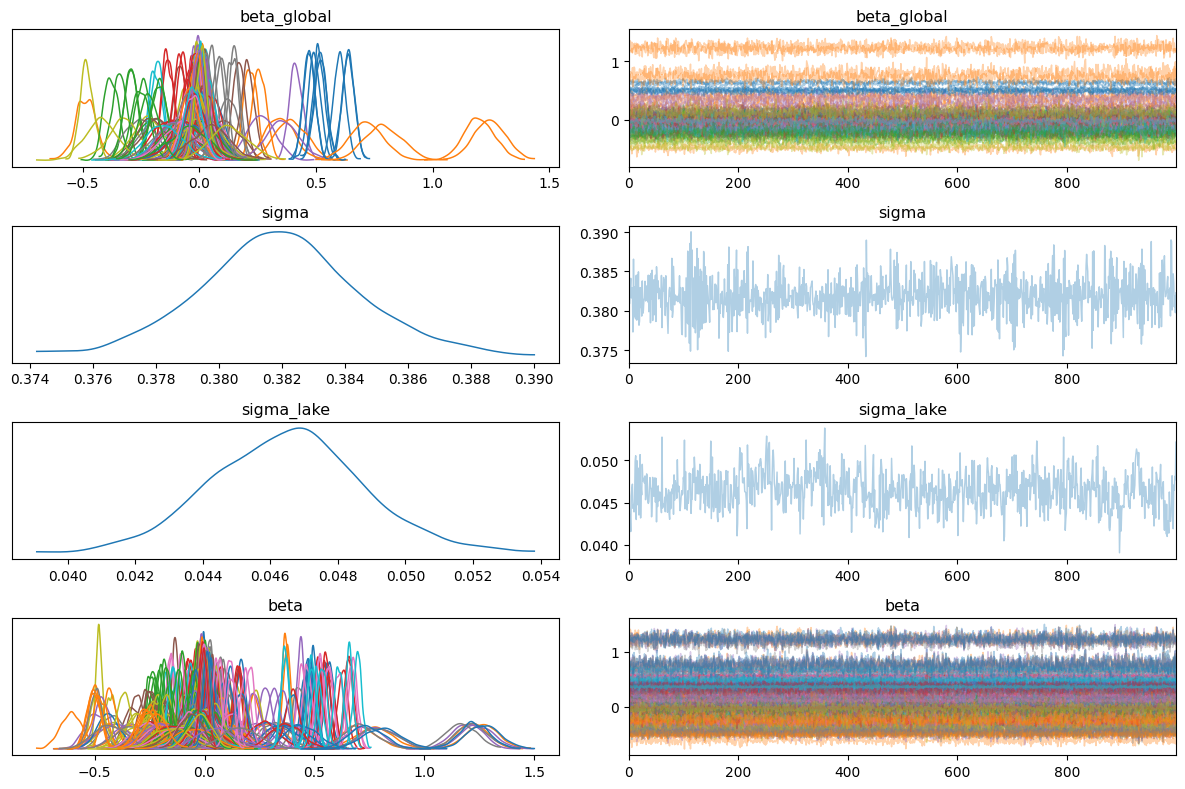

In [156]:
trace = az.from_numpyro(mcmc)
az.plot_trace(trace, var_names = ["beta_global", "sigma", "sigma_lake", "beta"])

plt.tight_layout()


## Prediction Function

In [157]:

# annoying, but we need to loop over the simulations to get the vmapping done
def make_predict_fn(model, mcmc):
    predict_fn = Predictive(model, mcmc.get_samples(), return_sites=["y_hat", "mu"])

    def predict(key, X):
        k1, _ = jax.random.split(key)
        pred_coeffs = predict_fn(k1, X)["y_hat"]
        
        # well, this is bad, but we're assuming a very set type of pipeline. 
        # This is the worst.
        all_coeffs = xr.DataArray(
                pred_coeffs,
                dims=["simulation", "start_date", "basis_dim", "lake"],
                coords=coord_set,
            ).expand_dims("variable").assign_coords(variable=["rnbs"]).transpose(
                "simulation", "start_date", "basis_dim", "lake", "variable"
            )
        
        original_scale = xr.concat([
            y_pipeline.inverse_transform(coeff)
            for coeff in all_coeffs
        ], dim="simulation")
        return original_scale
    return predict

predict = make_predict_fn(model, mcmc)

predictions = predict(jax.random.key(19900330), basis_covars.values)
predictions.shape

(1000, 349, 12, 4, 1)

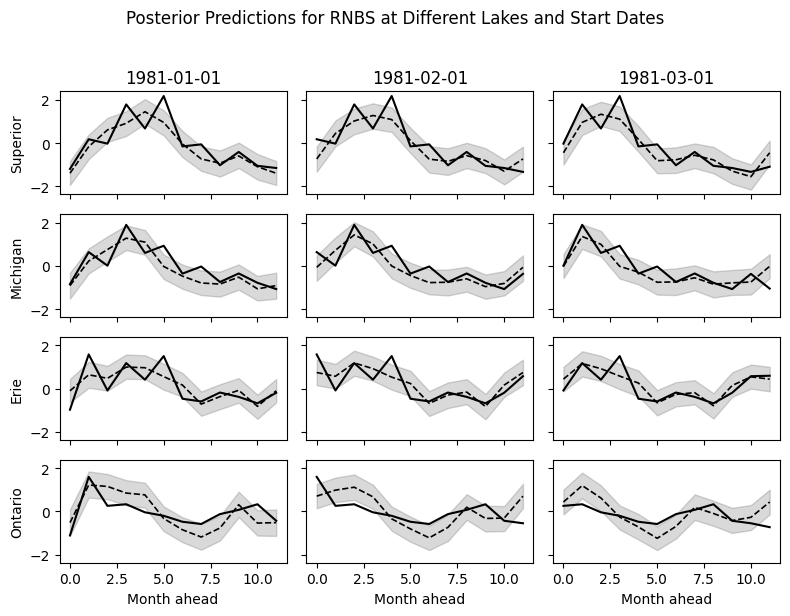

In [ ]:
pred_subsample = predictions[:, 0:9, :, :, :].squeeze().transpose("start_date", ...)
true_subsample = forecast[0:9, :, :, :].sel(variable="rnbs").squeeze().transpose("start_date", ...)

lake_lookup = {
    "sup": "Superior",
    "mic_hur": "Michigan",
    "eri": "Erie",
    "ont": "Ontario",
}
    
lakes = pred_subsample.coords["lake"].values
dates = pred_subsample.coords["start_date"].values[:3]  # 3 columns

fig, axes = plt.subplots(
    nrows=len(lakes),
    ncols=3,
    figsize=(8, 1.5 * len(lakes)),
    sharex=True,
    sharey=True,
)

axes = np.atleast_2d(axes)

for i, lake in enumerate(lakes):
    for j, date in enumerate(dates):

        ax = axes[i, j]

        preds = pred_subsample.sel(lake=lake, start_date=date)
        true  = true_subsample.sel(lake=lake, start_date=date)

        # posterior summaries
        mean = preds.mean(dim="simulation")
        lower = preds.quantile(0.05, dim="simulation")
        upper = preds.quantile(0.95, dim="simulation")

        t = np.arange(12)

        # uncertainty band
        ax.fill_between(
            t,
            lower.values,
            upper.values,
            color="black",
            alpha=0.15,
        )

        # posterior mean
        ax.plot(
            t,
            mean.values,
            linestyle="--",
            linewidth=1.2,
            color="black",
        )

        # observed truth
        ax.plot(
            t,
            true.values,
            linewidth=1.5,
            color="black",
        )

        # labels (minimal, but informative)
        if j == 0:
            ax.set_ylabel(lake_lookup[lake])
        if i == 0:
            ax.set_title(str(date))

for ax in axes[-1, :]:
    ax.set_xlabel("Month ahead")

plt.suptitle("Posterior Predictions for RNBS at Different Lakes and First Three Dates", y=1.02)
plt.tight_layout()
plt.show()



In [126]:
def fourier_basis(t, K, orthogonal=True):
    basis = [jnp.ones_like(t)]
    k = 1
    while len(basis) < K:
        basis.append(jnp.sin(2 * jnp.pi * k * t))
        if len(basis) < K:
            basis.append(jnp.cos(2 * jnp.pi * k * t))
        k += 1
    operator_matrix = jnp.stack(basis[:K], axis=1)
    if orthogonal:
        operator_matrix, _ = jnp.linalg.qr(operator_matrix)
    return operator_matrix

t = jnp.arange(12) / 12.0

covar_phi = fourier_basis(t, 8)
y_phi     = fourier_basis(t, 6)

covars = jnp.einsum(
    "ndlm,dk->nklm",
    forecast.sel(variable=["evap", "precip", "temp"]).values,
    covar_phi
)

y = jnp.einsum(
    "ndl,dq->nql",
    forecast.sel(variable="rnbs").values,
    y_phi
)

y_hat = jnp.einsum(
    "nql,dq->ndl",
    y,
    y_phi
)


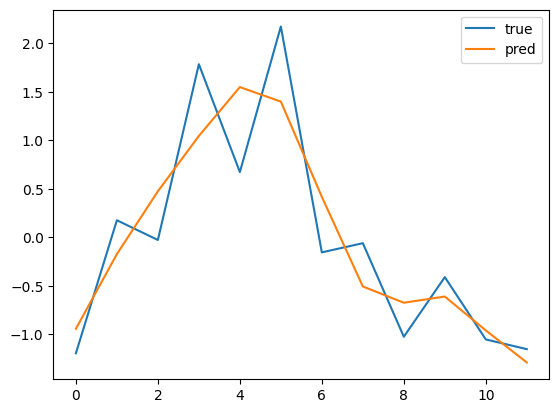

In [127]:
tmp = forecast.sel(variable="rnbs", lake="sup")[0]
tmp_hat = y_hat[0, :, 0]

plt.plot(tmp, label="true")
plt.plot(tmp_hat, label="pred")
plt.legend()
plt.show()

# Basis Representation

Across the four lakes, we want to represent each of these curves functionally, so we will be doing function on function regression. Because of the implied periodicity in our data, we will utilize the Fourier basis transformation.

## Single Lake

In [24]:
from skfda.representation.basis import BSplineBasis, FourierBasis
from sklearn.linear_model import (
    Lasso as SkLasso,
)
from sklearn.linear_model import (
    LinearRegression as SkLinear,
)
from sklearn.linear_model import (
    Ridge as SkRidge,
)
from sklearn.neural_network import MLPRegressor

basis_X = FourierBasis(n_basis=18, domain_range=(0.0, 35.0))
basis_Y = BSplineBasis(n_basis=6, domain_range=(0.0, 11.0))

fd_X_period = [
    skfda.FDataGrid(
        data_matrix=scaled_train[:, :, i], grid_points=np.arange(36)
    ).to_basis(basis_X)
    for i in range(scaled_train.shape[2])
]


fd_Y = skfda.FDataGrid(
    data_matrix=scaled_test[:, :, 0],
    grid_points=np.arange(12),
).to_basis(basis_Y)


X_coeff = np.hstack([fd.coefficients for fd in fd_X_period])


train_x, test_x, train_y, test_y, train_windows, test_windows = train_test_split(
    X_coeff, fd_Y.coefficients, training_windows, test_size=0.2, random_state=42
)

print(train_x.shape)


# model = MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=5000, random_state=42, learning_rate_init=0.01, learning_rate='adaptive')
model = SkRidge(alpha=0.5)
model.fit(train_x, train_y)

(1143, 76)


,alpha,0.5
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [17]:
y_coefficients = model.predict(test_x)

pred_fn = skfda.representation.basis.FDataBasis(
    basis=basis_Y, coefficients=y_coefficients
)
pred_grid = pred_fn.to_grid(np.arange(12)).data_matrix[:, :, 0]

true_vals = xr.concat(
    [
        clean_ds(train_xr[1], window_start=train_window_size).assign_coords(
            {"test_start_date": train_xr[1].coords["Date"].values[0]}
        )
        for train_xr in test_windows
    ],
    dim="test_start_date",
)[:, :, 0]

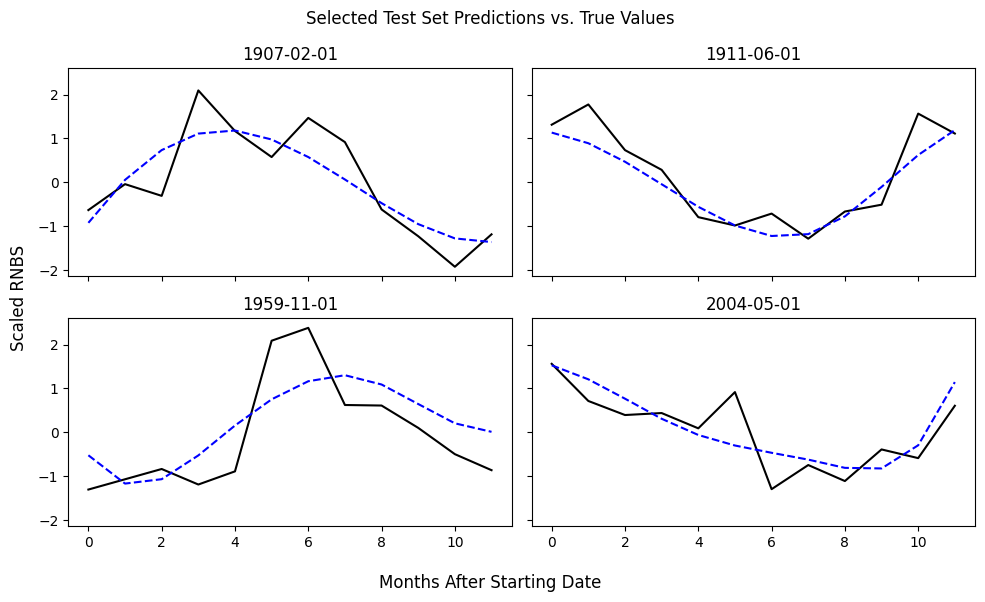

In [18]:
np.random.seed(20250607)
plot_idx = np.sort(rng.choice(len(test_windows), size=4, replace=False))

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = [
    "#000000",  # black
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
]

fig, ax = plt.subplots(figsize=(10, 6), sharex=True, sharey=True, ncols=2, nrows=2)
rng = np.random.default_rng(20250607)
for i, ax_idx in enumerate(ax.flatten()):
    idx = plot_idx[i]

    true, predicted = true_vals[idx, :], pred_grid[idx, :]
    ax_idx.plot(list(range(12)), true, label="True", color="black")
    ax_idx.plot(
        list(range(12)), predicted, linestyle="--", label="Predicted", color="blue"
    )
    ax_idx.set_title(
        np.datetime_as_string(true.coords["test_start_date"].values, unit="D")
    )

fig.supxlabel("Months After Starting Date")
fig.supylabel("Scaled RNBS")
fig.suptitle("Selected Test Set Predictions vs. True Values")
fig.tight_layout()

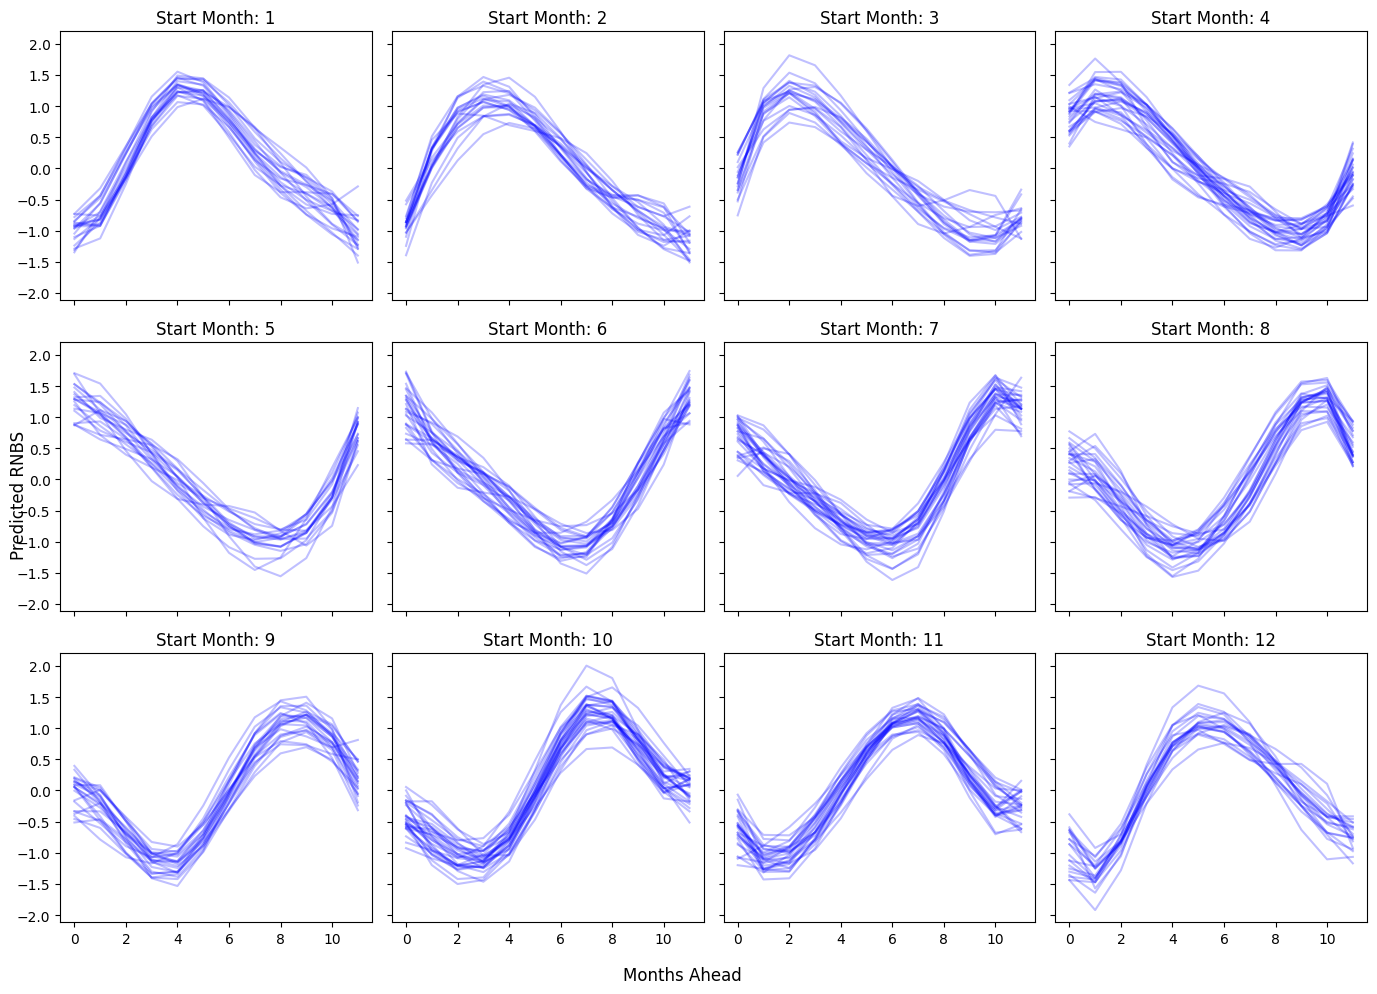

In [19]:
import pandas as pd

predictions = pd.DataFrame(pred_grid)
predictions["pred_dates"] = true_vals.coords["test_start_date"].values


dates = predictions["pred_dates"]
plot_data = predictions.melt(
    id_vars=["pred_dates"], var_name="month_ahead", value_name="predicted_rnbs"
)
plot_data["start_month"] = pd.to_datetime(plot_data["pred_dates"]).dt.month

fig, axes = plt.subplots(3, 4, figsize=(14, 10), sharey=True, sharex=True)
axes = axes.flatten()

for month, ax in zip(range(1, 13), axes):
    df_month = plot_data[plot_data["start_month"] == month]

    if df_month.empty:
        ax.set_title(f"Month {month} (no data)")
        continue

    for date, df in df_month.groupby("pred_dates"):
        ax.plot(df["month_ahead"], df["predicted_rnbs"], alpha=0.25, color="blue")

    ax.set_title(f"Start Month: {month}")

fig.supxlabel("Months Ahead")
fig.supylabel("Predicted RNBS")
plt.tight_layout()
plt.show()

In [20]:
np.sqrt(((true_vals - pred_grid) ** 2).mean())

<xarray.DataArray 'rnbs' ()> Size: 8B
array(0.5715907)
Coordinates:
    lake     <U3 12B 'sup'

## Multiple Lakes

In [21]:
# basis_X = FourierBasis(n_basis=12, domain_range=(0.0, 35.0))
# basis_Y = BSplineBasis(n_basis=6, domain_range=(0.0, 11.0))

fd_X_period = [
    skfda.FDataGrid(
        data_matrix=scaled_train[:, :, i], grid_points=np.arange(36)
    ).to_basis(basis_X)
    for i in range(scaled_train.shape[2])
]

fd_Y_lakes = [
    skfda.FDataGrid(
        data_matrix=scaled_test[:, :, i],
        grid_points=np.arange(12),
    ).to_basis(basis_Y)
    for i in range(scaled_test.shape[2])
]


X_coeff = np.hstack([fd.coefficients for fd in fd_X_period])
Y_coeff = np.hstack([fd.coefficients for fd in fd_Y_lakes])


train_x, test_x, train_y, test_y, train_windows, test_windows = train_test_split(
    X_coeff, Y_coeff, training_windows, test_size=0.2, random_state=42
)

print(train_x.shape)


# model = MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=5000, random_state=42, learning_rate_init=0.01, learning_rate='adaptive')
model = SkRidge(alpha=0.5)
model.fit(train_x, train_y)

(1143, 76)


,alpha,0.5
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [22]:
y_coefficients = model.predict(test_x)

y_coeff_matrix = y_coefficients.reshape(-1, basis_Y.n_basis, scaled_test.shape[2])


lake_fns = np.stack(
    [
        skfda.representation.basis.FDataBasis(
            basis=basis_Y, coefficients=y_coeff_matrix[:, :, i]
        )
        .to_grid(np.arange(12))
        .data_matrix[:, :, 0]
        for i in range(4)
    ],
    axis=2,
)

lake_fns.shape

(286, 12, 4)

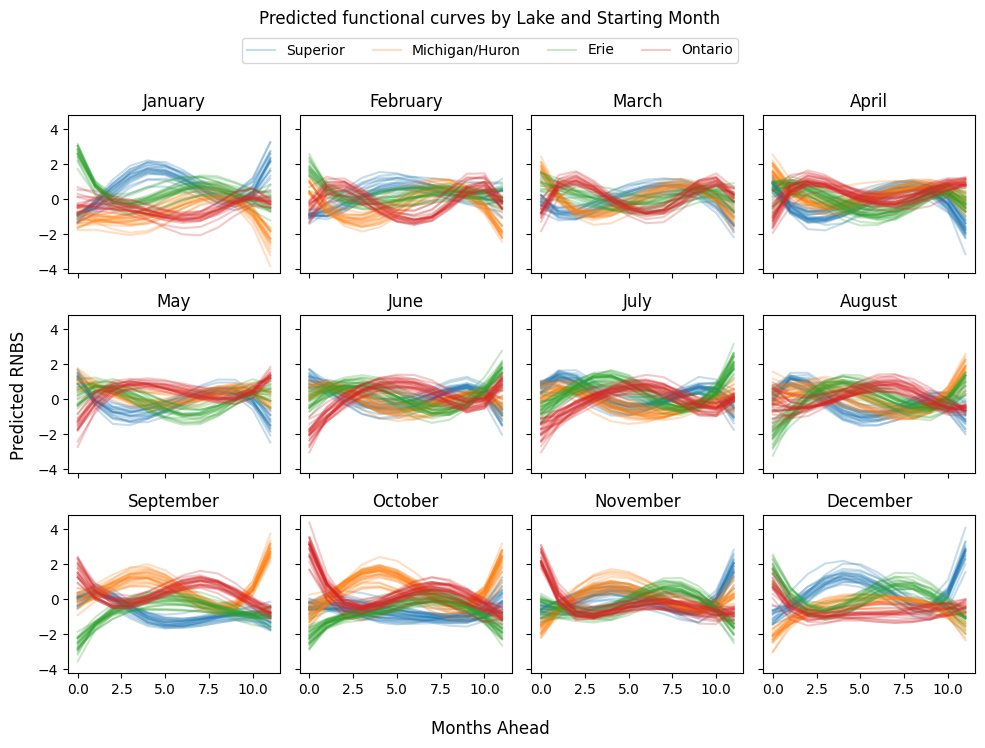

In [ ]:
# fixed colors for each lake
lake_colors = {
    "Superior": "#1f77b4",
    "Michigan/Huron": "#ff7f0e",
    "Erie": "#2ca02c",
    "Ontario": "#d62728",
}

months = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December",
}

fig, axes = plt.subplots(3, 4, figsize=(10, 7), sharey=True, sharex=True)
axes = axes.flatten()

for lake_idx, lake in enumerate(lake_colors.keys()):
    color = lake_colors[lake]

    predictions = pd.DataFrame(lake_fns[:, :, lake_idx])
    predictions["pred_dates"] = true_vals.coords["test_start_date"].values

    plot_data = predictions.melt(
        id_vars=["pred_dates"], var_name="month_ahead", value_name="predicted_rnbs"
    )
    plot_data["start_month"] = pd.to_datetime(plot_data["pred_dates"]).dt.month

    # loop over months and axes
    for month, ax in zip(range(1, 13), axes):
        df_month = plot_data[plot_data["start_month"] == month]

        if df_month.empty:
            ax.set_title(f"Month {month} (no data)")
            continue

        # draw all curves for this lake + this month in the same color
        for date, df in df_month.groupby("pred_dates"):
            ax.plot(
                df["month_ahead"],
                df["predicted_rnbs"],
                alpha=0.25,
                color=color,
                label=lake,
            )

        ax.set_title(months[month])

fig.supxlabel("Months Ahead")
fig.supylabel("Predicted RNBS")

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(
    by_label.values(),
    by_label.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
)
fig.suptitle("Predicted functional curves by Lake and Starting Month", y=1.05)

plt.tight_layout()
plt.show()